# Test evaluation of the best models

In [20]:
import cartopy
import matplotlib.pyplot as plt
import pandas as pd
import pathlib
import lightning
import rasterio
import torch
import xarray
import numpy as np

import models
import loss
import datasets

Experiments with scale factor 16

In [4]:
data = pd.read_csv('../data/results.csv')
data = data[data['scale_factor'] == 16]

Best unconstrained

In [5]:
unc = data.loc[(data['hard'] == 0) & (data['soft'] == 0)]
unc.loc[unc['rmse'] == unc['rmse'].min()]

,experiment,group,scale_factor,alpha,mae,rmse,features,residual_blocks,model,patience,lr,wd,soft,hard,version,resampling,data,parameters,exp_group
17,469,1,16,NaN,0.02983,0.04135,128,64,EDSR,15,0.0001,0.00001,0,0,mae,cubic_spline,ReKIS,21402113,1


Best soft constrained

In [6]:
soft = data.loc[(data['hard'] == 0) & (data['soft'] == 1)]
soft.loc[soft['rmse'] == soft['rmse'].min()]

,experiment,group,scale_factor,alpha,mae,rmse,features,residual_blocks,model,patience,lr,wd,soft,hard,version,resampling,data,parameters,exp_group
83,506,3,16,0.0001,0.02709,0.0358,128,64,EDSR,15,0.0001,0.00001,1,0,mae,average,ReKIS,21402113,3
104,525,3,16,0.0001,0.02709,0.0358,128,64,EDSR,15,0.0001,0.00001,1,0,mae,average,ReKIS,21402113,4


Best hard constrained

In [7]:
hard = data.loc[(data['hard'] == 1) & (data['soft'] == 0)]
hard.loc[hard['rmse'] == hard['rmse'].min()]

,experiment,group,scale_factor,alpha,mae,rmse,features,residual_blocks,model,patience,lr,wd,soft,hard,version,resampling,data,parameters,exp_group
78,629,12,16,NaN,0.02603,0.0315,128,64,EDSR,15,0.0001,0.00001,0,1,mae,average,ReKIS,21402113,2


Hard constrained model test eval

In [8]:
CKPT_DIR = '/home/tomas/ctu/current/rci_home/SISR-downscaling/logs/lightning_logs/'
def load_checkpoint(version: int):
    dir = pathlib.Path(CKPT_DIR + f'version_{version}/checkpoints/')
    return [file for file in dir.iterdir() if file.is_file() and file.suffix == '.ckpt'][0]

torch.set_float32_matmul_precision("high")
ckpt = load_checkpoint(629)

model = models.ConstrainedModel.load_from_checkpoint(checkpoint_path = ckpt,
                                                     model=models.EDSR(channels=1, scale_factor=16, features=128, residual_blocks=64, loss=loss.LossCombination([1], [
                                                         loss.L1Loss()])),
                                                     constraint=models.AddConstraintLayer(16)).cuda()
model.eval()

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'constraint' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['constraint'])`.


ConstrainedModel(
  (train_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=train/
  )
  (val_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=val/
  )
  (test_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=test/
  )
  (model): EDSR(
    (train_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=train/
    )
    (val_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=val/
    )
    (test_metrics): MetricCollection(
      (mae): MeanAbsoluteError()
      (mse): MeanSquaredError()
      (rmse): MeanSquaredError(),
      prefix=test/
    )
    (loss): LossCombination(


ReKIS dataset

In [9]:
PATH_ReKIS = '/rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/'

# we will not use any other than test dataloader
rekis_dm = datasets.ReKISDataModule(16, PATH_ReKIS, ["2003", "2003", "2003", "2003", "2003", "2012"], 16)

rekis_dm.setup(None)

test_loader = rekis_dm.test_dataloader()

MAE of pixels calculation on test set

In [10]:
error = torch.zeros(1, 1, 400, 400)

images_num = 0
with torch.no_grad():
    for i, (x, y) in enumerate(test_loader):
        images_num += x.shape[0]

        y_hat = model(x.cuda()).cpu()

        error += (y - y_hat).abs().sum(dim=0).squeeze()

error /= images_num

In [11]:
error

tensor([[[[0.0395, 0.0343, 0.0305,  ..., 0.0305, 0.0387, 0.0478],
          [0.0327, 0.0324, 0.0285,  ..., 0.0326, 0.0332, 0.0375],
          [0.0289, 0.0294, 0.0274,  ..., 0.0287, 0.0344, 0.0368],
          ...,
          [0.0330, 0.0304, 0.0278,  ..., 0.0411, 0.0451, 0.0490],
          [0.0364, 0.0323, 0.0283,  ..., 0.0441, 0.0503, 0.0561],
          [0.0394, 0.0324, 0.0305,  ..., 0.0506, 0.0581, 0.0689]]]])

In [14]:
left, bottom, right, top = 4335000, 5555000, 4755000, 5955000

easting  = np.linspace(left, right, 400)
northing = np.linspace(top, bottom, 400)

im_error = xarray.DataArray(
    error.squeeze().numpy(),
    dims=["northing", "easting"],
    coords={
        "northing": northing,
        "easting":  easting,
    },
    name = 'tas'
)
im_error = im_error.rio.write_crs("EPSG:31468")
im_error = im_error.rio.set_spatial_dims(x_dim="easting", y_dim="northing")
im_error.attrs['units'] = '°C'

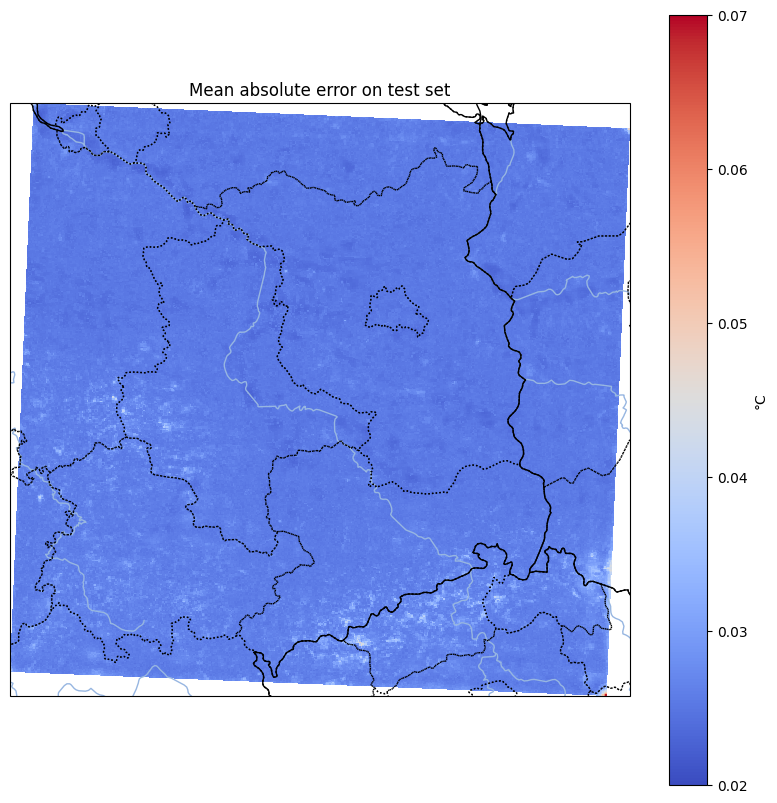

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(projection=cartopy.crs.UTM(33)))

im_error.plot(cmap='coolwarm', transform=cartopy.crs.epsg(31468), vmin=0.02, vmax=0.07, ax=ax, cbar_kwargs={'label' : '°C'})
ax.add_feature(cartopy.feature.RIVERS)
ax.add_feature(cartopy.feature.COASTLINE)
ax.add_feature(cartopy.feature.BORDERS)
ax.add_feature(cartopy.feature.STATES, linestyle=':')

ax.set_title('Mean absolute error on test set')
fig.savefig('images/mae.png', bbox_inches='tight', dpi=300)
plt.show()

Mountainous region slightly higher

Test set performance calculation.

In [10]:
trainer = lightning.Trainer(accelerator='cuda')
trainer.test(model, test_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/core/saving.py:363: Skipping 'model' parameter because it is not possible to safely dump to YAML.
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │   0.025749946013092995    │
│         test/mae          │    0.02574992924928665    │
│         test/mse          │   0.0009364637080579996   │
│         test/rmse         │    0.03060169517993927    │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.025749946013092995,
  'test/mae': 0.02574992924928665,
  'test/mse': 0.0009364637080579996,
  'test/rmse': 0.03060169517993927}]

Soft constraint

In [11]:
ckpt = load_checkpoint(506)

model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt, channels=1, scale_factor=16, features=128, residual_blocks=64, loss=loss.LossCombination([0.9999, 0.0001], [
    loss.L1Loss(), loss.SoftSimpleGradientLoss(16, 'mae')])).cuda()
model.eval()

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.


EDSR(
  (train_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=train/
  )
  (val_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=val/
  )
  (test_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=test/
  )
  (loss): LossCombination(
    (losses): ModuleList(
      (0): L1Loss(
        (l1): L1Loss()
      )
      (1): SoftSimpleGradientLoss(
        (pixel_unshuffle): PixelUnshuffle(downscale_factor=16)
        (penalization): L1Loss()
      )
    )
  )
  (head): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (body): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv

In [12]:
trainer = lightning.Trainer(accelerator='cuda')
trainer.test(model, test_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.02666318416595459    │
│         test/mae          │    0.02666552923619747    │
│         test/mse          │   0.0011426361743360758   │
│         test/rmse         │    0.03380290046334267    │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.02666318416595459,
  'test/mae': 0.02666552923619747,
  'test/mse': 0.0011426361743360758,
  'test/rmse': 0.03380290046334267}]

For the unconstrained model, the cubic_spline resampling method was the best, however that is not a parameter, so we will copy the code from src/datasets/rekis.py

In [13]:
RESAMPLING = rasterio.enums.Resampling.cubic_spline

class ReKIS(torch.utils.data.Dataset):
    """Dataset for ReKIS."""

    def __init__(self, Y: xarray.DataArray, scale_factor : int):
        """
        Initialize the dataset with target.
        The target is upscaled and used as input for the model.
        Args:
            Y : xarray.DataArray    target variable
            scale_factor : int
        """
        self.scale_factor = scale_factor

        Y = Y.isel(easting=slice(0, 400), northing=slice(0, 400))
        Y.rio.set_spatial_dims("easting", "northing")

        resolution = 1000 * self.scale_factor
        X = Y.rio.reproject(
            Y.rio.crs, resolution=(resolution, resolution), resampling=RESAMPLING
        )
        self.X = torch.from_numpy(X.values).unsqueeze(1)
        self.Y = torch.from_numpy(Y.values).unsqueeze(1)


    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, index: int):
        return self.X[index], self.Y[index]


class ReKISDataModule(lightning.LightningDataModule):
    """DataModule for ReKIS."""

    def __init__(self, batch_size: int, path: str, sets_years: list, scale_factor : int):
        """
        Initialize the DataModule.
        Args:
            batch_size : int
            path : str              path to ReKIS
            sets_years : list[int]  division of dataset into train, val and test sets
            scale_factor : int
        """
        super().__init__()
        self.batch_size = batch_size
        self.path = path
        self.sets_years = sets_years
        self.scale_factor = scale_factor

    def setup(self, stage):
        """
        Loads, splits and saves data.
        """
        variable = "TM"
        Y = xarray.open_mfdataset(self.path + variable + "/*.nc", decode_coords="all", decode_timedelta=False)
        Y = Y[variable]
        self.testset = ReKIS(Y.sel(time=slice(self.sets_years[4], self.sets_years[5])), self.scale_factor)

    def test_dataloader(self) -> torch.utils.data.DataLoader:
        """Returns a DataLoader for the test set."""
        return torch.utils.data.DataLoader(self.testset, batch_size=self.batch_size, num_workers=8)


In [14]:
rekis_dm = ReKISDataModule(16, PATH_ReKIS, [ "1961", "1992", "1993", "2002", "2003", "2012" ], 16)

rekis_dm.setup(None)

test_loader = rekis_dm.test_dataloader()

In [15]:
ckpt = load_checkpoint(469)

model = models.EDSR.load_from_checkpoint(checkpoint_path = ckpt, channels=1, scale_factor=16, features=128, residual_blocks=64, loss=loss.LossCombination([1], [
    loss.L1Loss()])).cuda()
model.eval()

/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.


EDSR(
  (train_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=train/
  )
  (val_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=val/
  )
  (test_metrics): MetricCollection(
    (mae): MeanAbsoluteError()
    (mse): MeanSquaredError()
    (rmse): MeanSquaredError(),
    prefix=test/
  )
  (loss): LossCombination(
    (losses): ModuleList(
      (0): L1Loss(
        (l1): L1Loss()
      )
    )
  )
  (head): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (body): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0

In [16]:
trainer = lightning.Trainer(accelerator='cuda')
trainer.test(model, test_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/tomas/ctu/current/.bpr/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │   0.029292097315192223    │
│         test/mae          │   0.029292091727256775    │
│         test/mse          │   0.0015101535245776176   │
│         test/rmse         │    0.03886069357395172    │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.029292097315192223,
  'test/mae': 0.029292091727256775,
  'test/mse': 0.0015101535245776176,
  'test/rmse': 0.03886069357395172}]

The best performance on the test set was achieved for the hard-constrained model (RMSE 0.0306), then for the soft-constrained (RMSE 0.0338).
The worst was the unconstrained model with RMSE 0.03886.